# Document redaction pipeline — minimal demo

Runs an offline screenshot redaction flow on one image:

1. **OCR** with RapidOCR (`rapidocr-onnxruntime`) → text + boxes.
2. **PII detection** with `openai/privacy-filter` when available.
3. **Fallback rules** for email/phone/secret-like text when the model is unavailable.
4. **Blur** the matching regions with Pillow and show before/after.

> **Demo only.** The production path should run in the Celery `vision` worker, only on evidence frames, and should use the lightweight ONNX privacy model path instead of forcing `torch` into the API image.

Leave `IMAGE_SOURCE` blank to use the generated sample image, or point it at any PNG/JPG URL/local path.


In [4]:
# Optional notebook-only dependencies. Keep this out of the API Docker image.
# First run can take a while, especially if torch/model weights are downloaded.
%pip install -q -U rapidocr-onnxruntime onnxruntime transformers torch pillow requests numpy huggingface_hub



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import getpass
import io
import os
import re
from pathlib import Path
from typing import Any

import numpy as np
import requests
from PIL import Image, ImageDraw, ImageFilter, ImageFont

try:
    from IPython.display import display
except Exception:
    def display(*objects):
        for obj in objects:
            print(obj)

# Blank means: generate a small deterministic sample image below.
IMAGE_SOURCE = "/Users/pratap/Downloads/redaction_test.png"
SCORE_THRESHOLD = 0.5
BLUR_RADIUS = 14
MAX_DIMENSION = 1600
OUTPUT_PATH = Path("redacted_output.png")

# Hugging Face token: never hard-code it in the notebook.
# Preferred: export HF_TOKEN=... before opening Jupyter.
# If needed interactively, uncomment the getpass line below.
HF_TOKEN = os.environ.get("HF_TOKEN", "").strip()
# HF_TOKEN = getpass.getpass("HF token: ").strip()

PII_LABELS = {
    "private_email",
    "private_phone",
    "private_person",
    "private_address",
    "private_url",
    "private_date",
    "account_number",
    "secret",
}

RULE_PATTERNS = {
    "email": re.compile(r"\b[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}\b", re.I),
    "phone": re.compile(r"(?<![A-Za-z0-9])(?:\+?\d[\d\s().-]{7,}\d)(?![A-Za-z0-9])"),
    "api_key": re.compile(r"\b(?:sk|pk|api|token|secret)[-_]?[A-Za-z0-9]{12,}\b", re.I),
}


image: (1254, 1600)


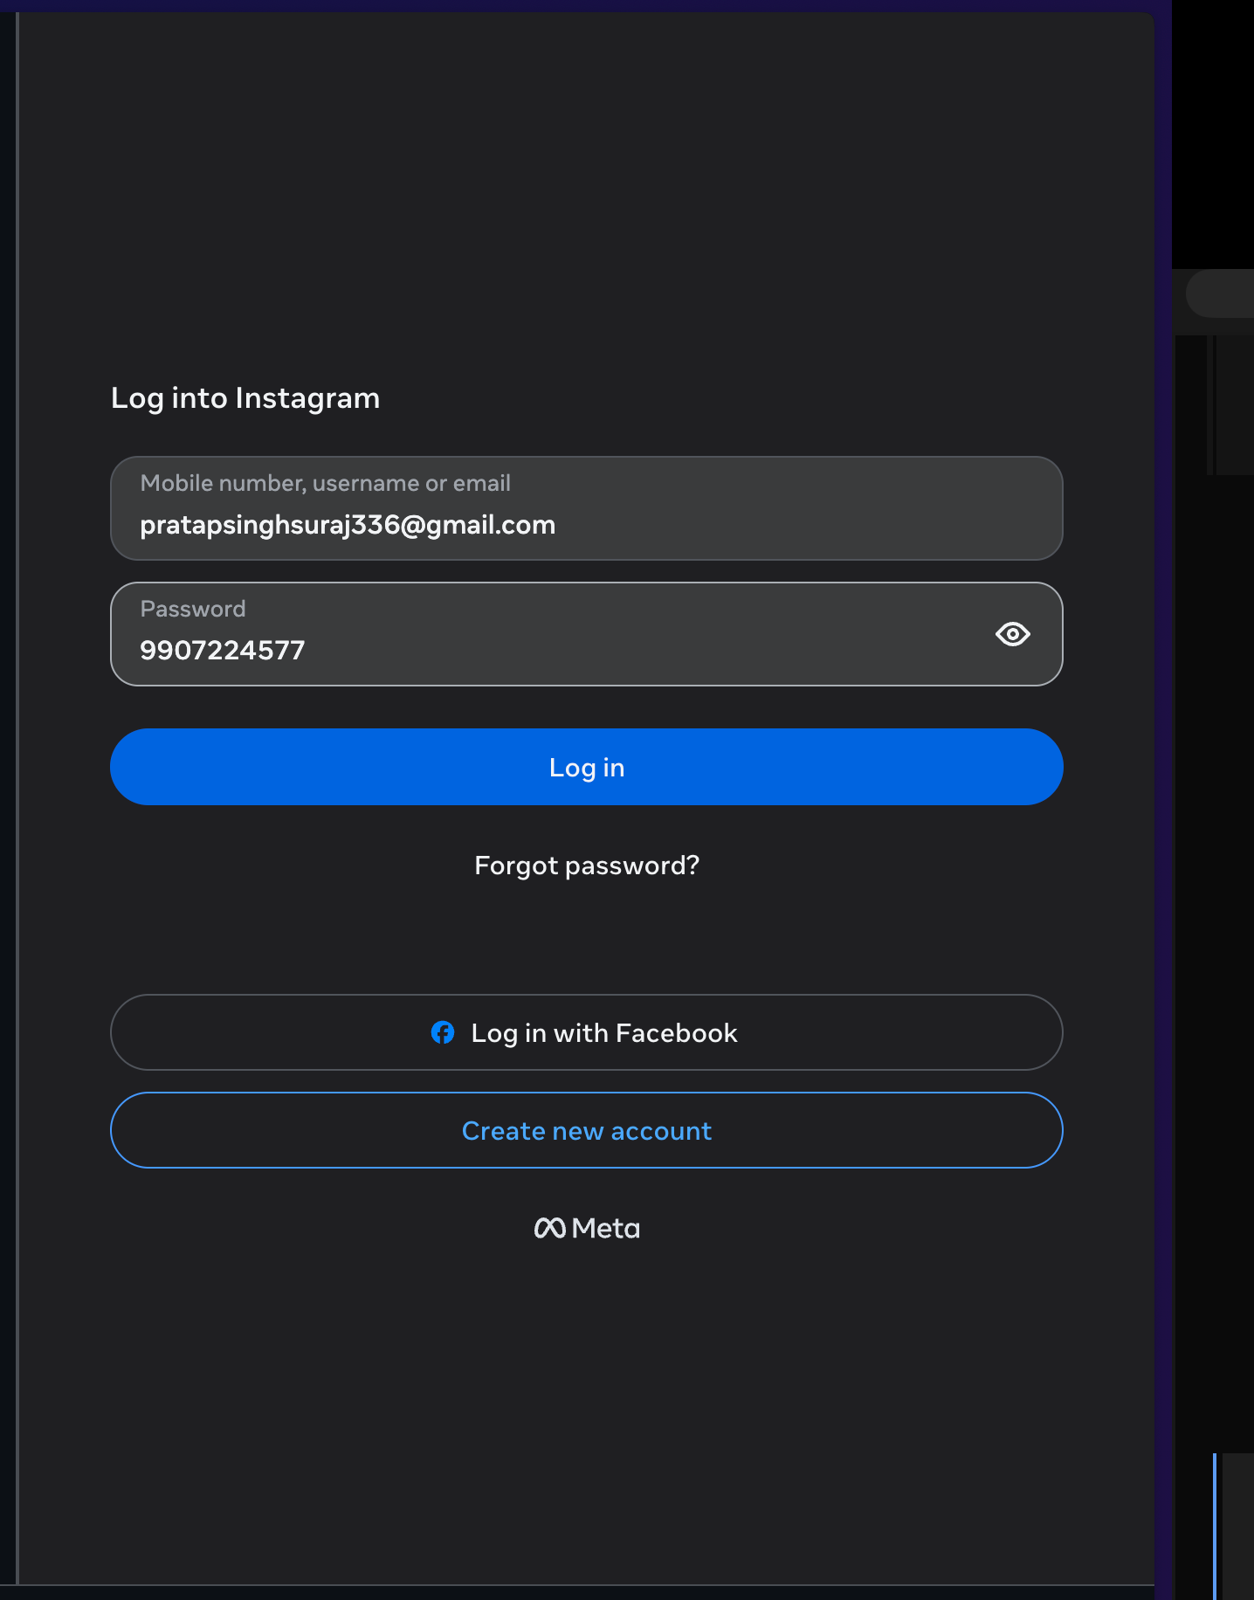

In [6]:


def load_image(source: str) -> tuple[Image.Image, list[tuple[list[list[float]], str, float]] | None]:
    source = source.strip()
    if not source or source == "PASTE_PNG_URL_OR_LOCAL_PATH":
        print("Please provide a valid image source (URL or local path).")
        return None, None

    path = Path(source).expanduser()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return Image.open(path).convert("RGB"), None


img, fallback_ocr_result = load_image(IMAGE_SOURCE)
if max(img.size) > MAX_DIMENSION:
    scale = MAX_DIMENSION / max(img.size)
    img = img.resize((int(img.width * scale), int(img.height * scale)))
    fallback_ocr_result = None  # Generated boxes no longer match after resizing.

print("image:", img.size)
display(img)


In [7]:
def load_ocr_engine() -> Any | None:
    try:
        from rapidocr_onnxruntime import RapidOCR
    except Exception as exc:
        print(f"RapidOCR unavailable; using sample OCR boxes if present. ({exc})")
        return None
    return RapidOCR()


def load_pii_classifier() -> Any | None:
    try:
        from transformers import pipeline
    except Exception as exc:
        print(f"transformers unavailable; using regex fallback only. ({exc})")
        return None

    token = HF_TOKEN or None
    if token:
        os.environ["HF_TOKEN"] = token
        try:
            from huggingface_hub import login

            login(token=token, add_to_git_credential=False)
        except Exception as exc:
            print(f"HF login skipped; downloads will still try with HF_TOKEN env. ({exc})")
    else:
        print("HF_TOKEN is not set; model downloads may be rate-limited.")

    try:
        return pipeline(
            "token-classification",
            model="openai/privacy-filter",
            aggregation_strategy="simple",
            token=token,
        )
    except Exception as exc:
        print(f"privacy-filter unavailable; using regex fallback only. ({exc})")
        return None


print("loading OCR + optional privacy model...")
ocr_engine = load_ocr_engine()
pii_classifier = load_pii_classifier()
print("ready")


loading OCR + optional privacy model...


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]

ready


In [8]:
def normalize_ocr_result(raw: Any) -> list[tuple[list[list[float]], str, float]]:
    result = raw[0] if isinstance(raw, tuple) else raw
    if not result:
        return []

    normalized = []
    for item in result:
        if len(item) < 3:
            continue
        box, text, confidence = item[:3]
        normalized.append((box, str(text), float(confidence)))
    return normalized


if ocr_engine is not None:
    ocr_result = normalize_ocr_result(ocr_engine(np.array(img)))
elif fallback_ocr_result is not None:
    ocr_result = fallback_ocr_result
else:
    raise RuntimeError(
        "OCR is unavailable and no generated sample boxes exist. "
        "Install rapidocr-onnxruntime or leave IMAGE_SOURCE blank for the sample."
    )

print(f"OCR detected {len(ocr_result)} text region(s)")
for _box, text, confidence in ocr_result[:10]:
    print(f"  [{confidence:.2f}] {text}")


OCR detected 10 text region(s)
  [1.00] Log into Instagram
  [0.97] Mobile number, username or email
  [0.98] pratapsinghsuraj336@gmail.com
  [1.00] Password
  [1.00] 9907224577
  [0.94] Log in
  [1.00] Forgot password?
  [1.00] Log in with Facebook
  [0.98] Create new account
  [0.83] 00 Meta


In [9]:
def model_hits(text: str) -> list[dict[str, Any]]:
    if pii_classifier is None:
        return []

    hits = pii_classifier(text)
    return [
        hit
        for hit in hits
        if hit.get("entity_group") in PII_LABELS
        and float(hit.get("score", 0)) >= SCORE_THRESHOLD
    ]


def rule_hits(text: str) -> list[dict[str, Any]]:
    hits = []
    for label, pattern in RULE_PATTERNS.items():
        for match in pattern.finditer(text):
            hits.append({"entity_group": label, "score": 1.0, "word": match.group(0)})
    return hits


redactions = []
for box, text, _confidence in ocr_result:
    text = (text or "").strip()
    if not text:
        continue

    hits = model_hits(text) or rule_hits(text)
    if hits:
        redactions.append(
            {
                "box": box,
                "text": text,
                "labels": sorted({str(hit["entity_group"]) for hit in hits}),
                "score": max(float(hit.get("score", 0)) for hit in hits),
            }
        )

print(f"redacting {len(redactions)} of {len(ocr_result)} region(s)")
for item in redactions:
    print(f"  {item['labels']} ({item['score']:.2f}): {item['text']}")


redacting 2 of 10 region(s)
  ['private_email'] (1.00): pratapsinghsuraj336@gmail.com
  ['phone'] (1.00): 9907224577


original  ->  redacted


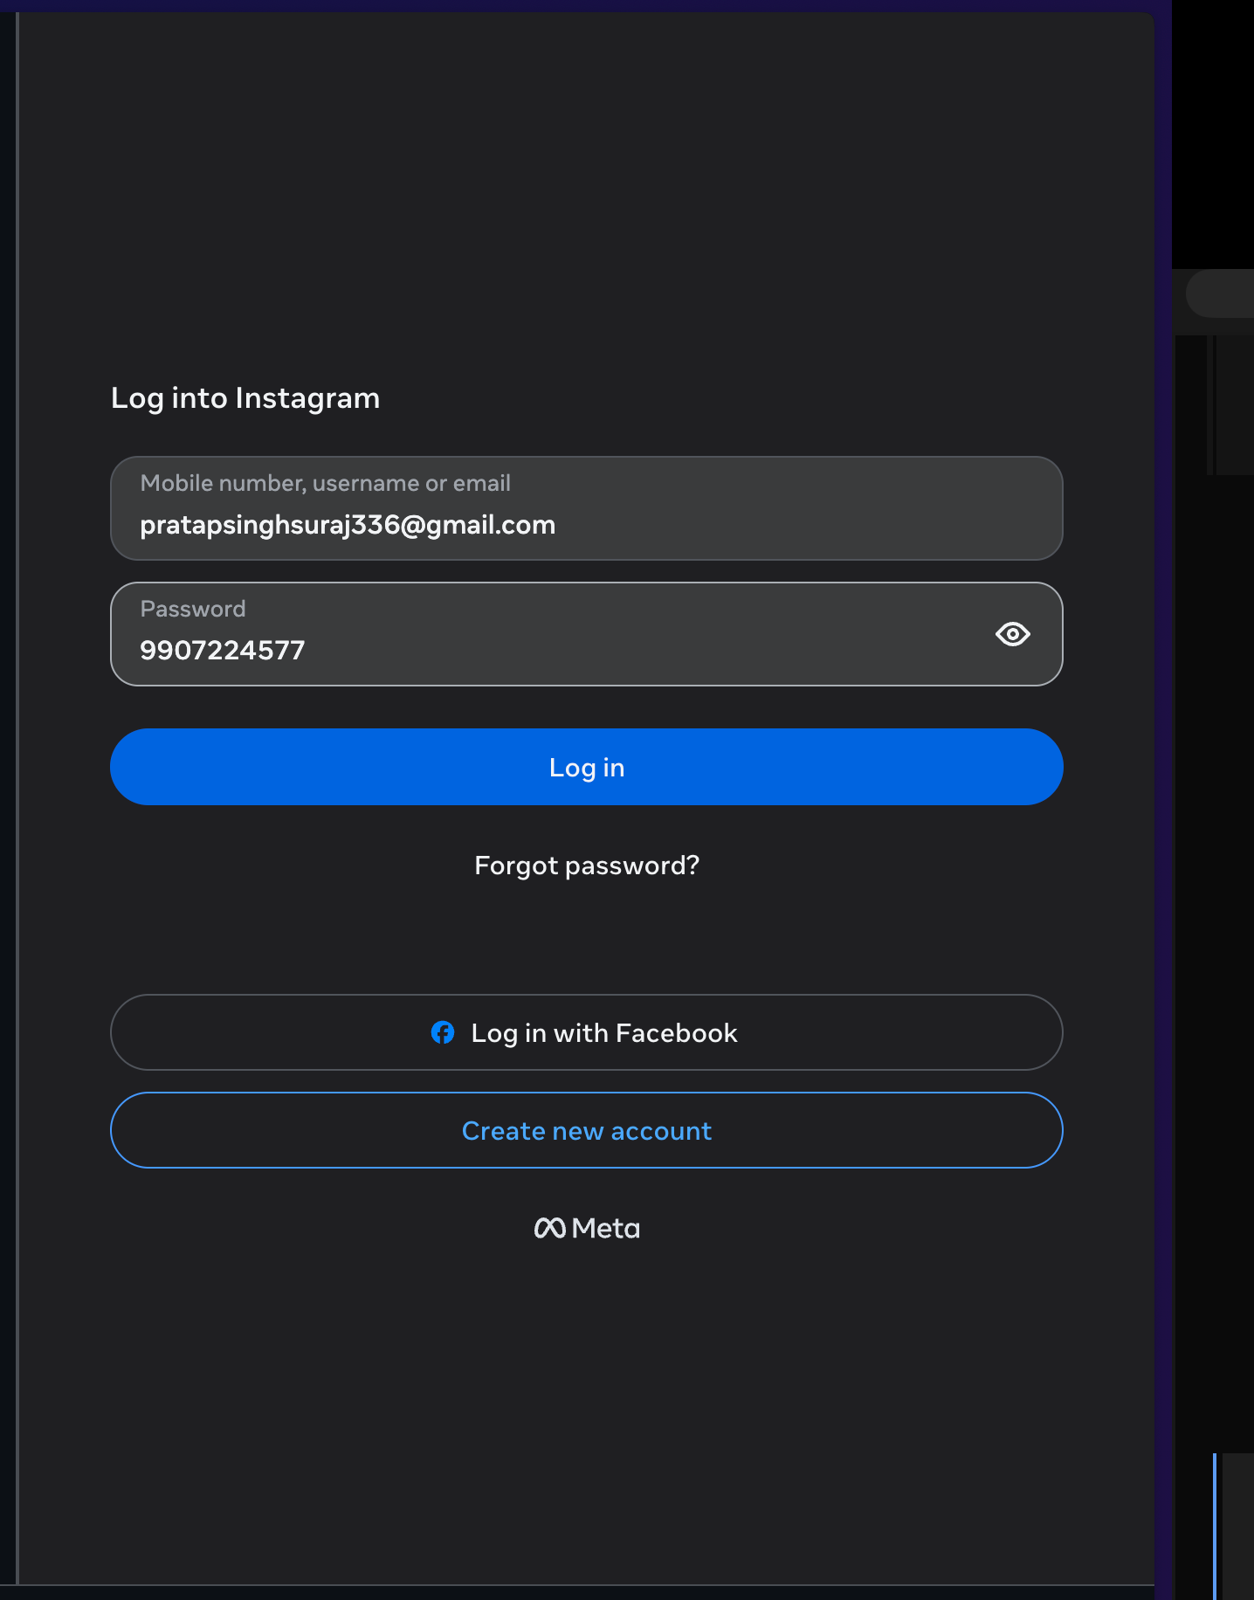

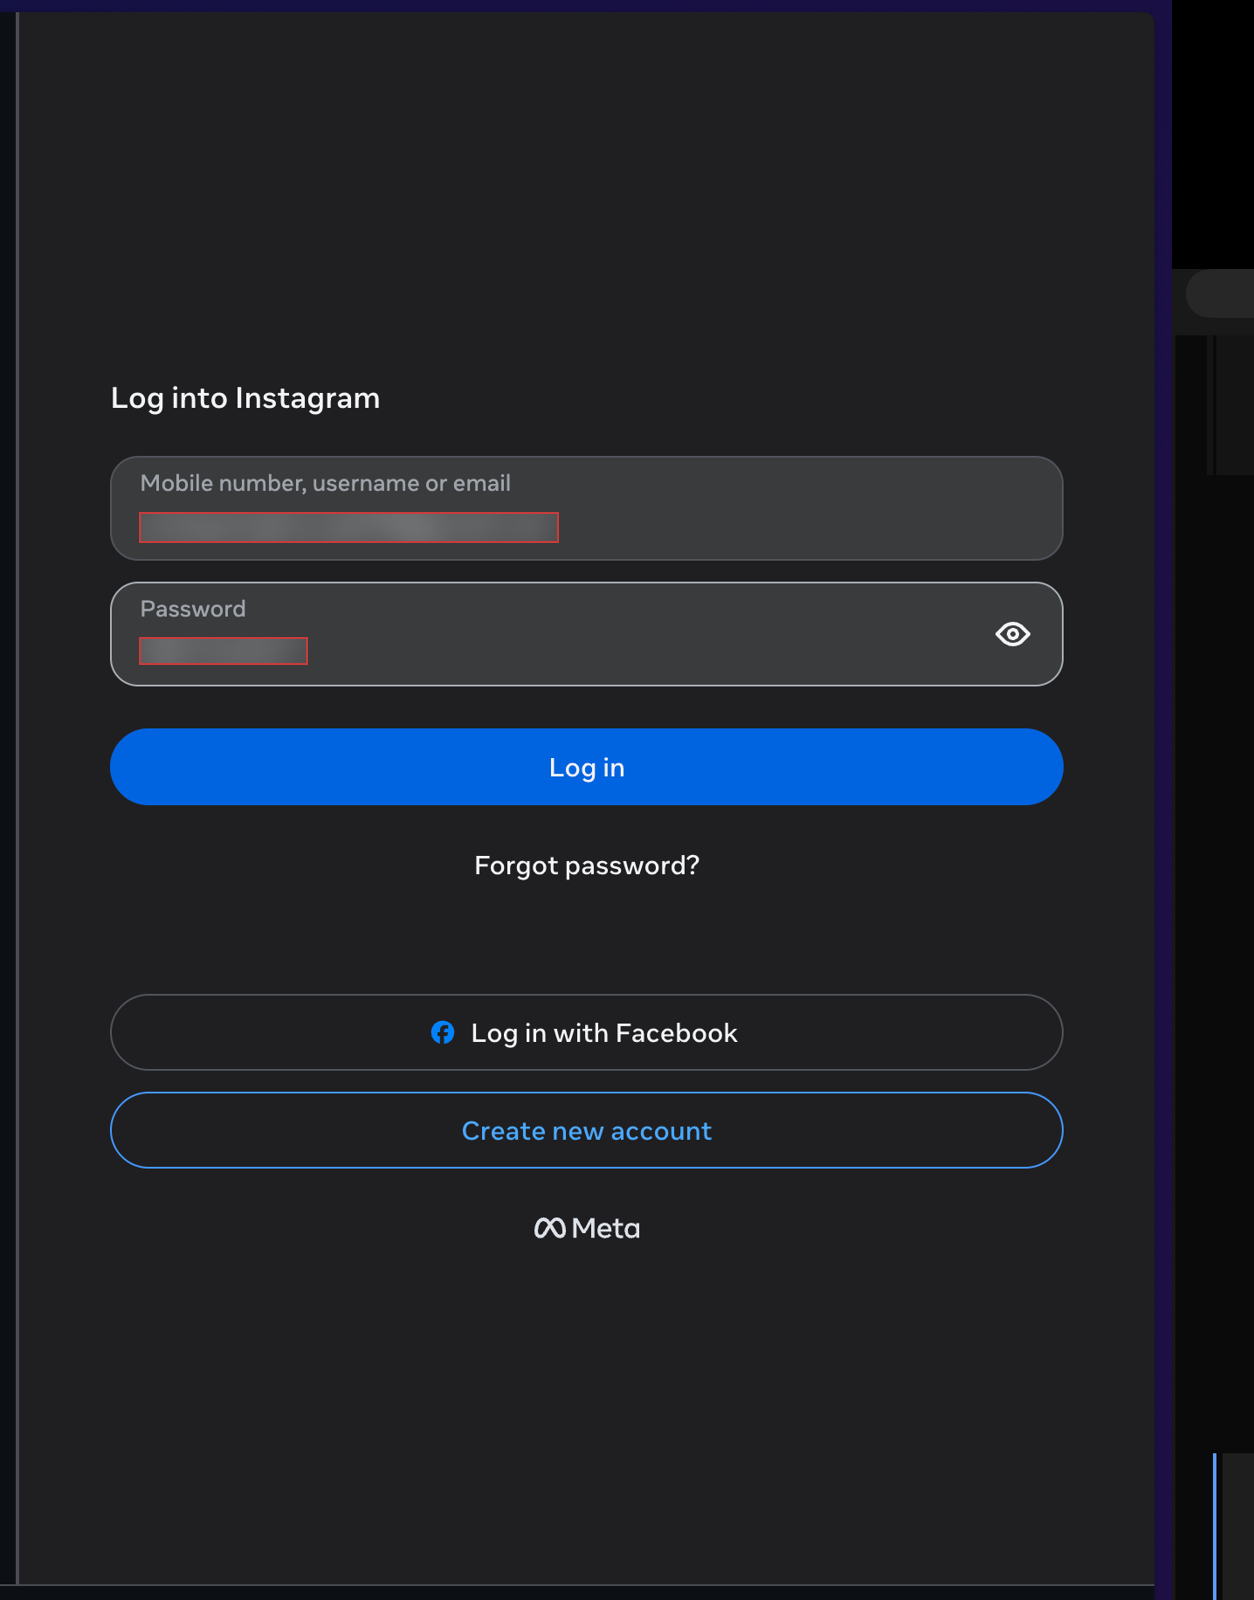

saved: /Volumes/Fatboi/frappe/apps/api/notebooks/redacted_output.png


In [10]:
def box_rect(box: list[list[float]]) -> tuple[int, int, int, int]:
    xs = [point[0] for point in box]
    ys = [point[1] for point in box]
    x0, y0, x1, y1 = int(min(xs)), int(min(ys)), int(max(xs)), int(max(ys))
    return max(0, x0), max(0, y0), min(img.width, x1), min(img.height, y1)


redacted = img.copy()
for item in redactions:
    x0, y0, x1, y1 = box_rect(item["box"])
    if x1 <= x0 or y1 <= y0:
        continue
    crop = redacted.crop((x0, y0, x1, y1)).filter(
        ImageFilter.GaussianBlur(radius=BLUR_RADIUS)
    )
    redacted.paste(crop, (x0, y0))

# Draw a subtle red outline so the demo makes clear what was redacted.
draw = ImageDraw.Draw(redacted)
for item in redactions:
    draw.rectangle(box_rect(item["box"]), outline=(200, 60, 60), width=2)

print("original  ->  redacted")
display(img, redacted)

redacted.save(OUTPUT_PATH)
print("saved:", OUTPUT_PATH.resolve())


## Toward production

- **Runtime:** swap `transformers` + `torch` for an ONNX privacy-filter path or another lightweight local recognizer so the API image stays lean.
- **Finer regions:** this demo redacts the whole OCR line when any PII span is found (recall over precision). Production should map PII spans to exact OCR word boxes and union those.
- **Rules too:** keep deterministic regex rules from `privacy.py` for org-specific identifiers the model taxonomy cannot see.
- **Wiring:** this belongs in `tasks/annotation.py` on the `vision` Celery queue, per-frame and resumable.
- **Cost:** OCR dominates (~1–3 s/frame CPU), so scope to evidence frames and downscale before detection.
